Optimal threshold = 0.65, cost = 0.1263


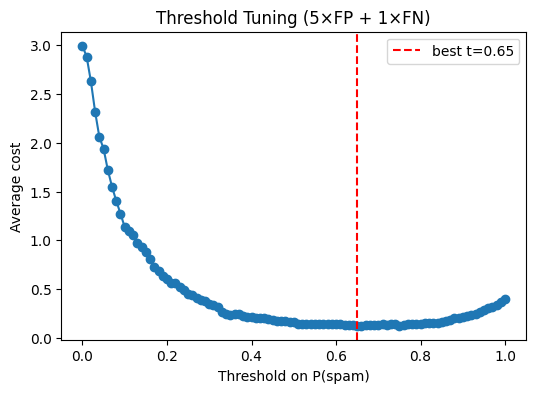


Confusion Matrix:
[[344   2]
 [ 28 204]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       346
           1       0.99      0.88      0.93       232

    accuracy                           0.95       578
   macro avg       0.96      0.94      0.94       578
weighted avg       0.95      0.95      0.95       578



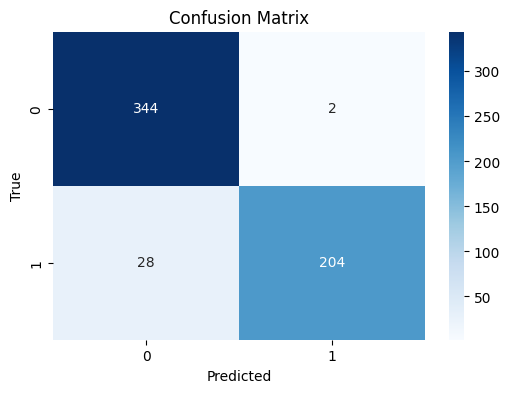


Validation Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96       346
           1       0.99      0.88      0.93       232

    accuracy                           0.95       578
   macro avg       0.96      0.94      0.94       578
weighted avg       0.95      0.95      0.95       578


Predictions saved to 'predicted_RF_threshold.txt'.


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. Load & Prepare the Data
# ----------------------------
# filtered_train_df: your labeled DataFrame (57 features + 'response' where 1=non-spam, 2=spam)
# test_df:          your unlabeled DataFrame (same 57 features, no 'response' column)
filtered_train_df = pd.read_csv('filtered_train.csv')
X = filtered_train_df.drop('response', axis=1)
y = filtered_train_df['response'].map({1: 0, 2: 1})   # map to {0=non-spam, 1=spam}

# ----------------------------
# 2. Split the Data
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ----------------------------
# 3. Scale the Features
# ----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# ----------------------------
# 4. Train initial Random Forest (uniform weights)
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# ----------------------------
# 5. Tune decision threshold on validation set
# ----------------------------
# 5.1 Get P(spam)
p_spam_val = rf.predict_proba(X_val_scaled)[:, 1]

# 5.2 Define cost function
def compute_cost(y_true, p_spam, thresh):
    preds = (p_spam >= thresh).astype(int)
    fp = ((preds == 1) & (y_true == 0)).sum()  # non-spam → spam
    fn = ((preds == 0) & (y_true == 1)).sum()  # spam → non-spam
    return (5 * fp + 1 * fn) / len(y_true)

# 5.3 Scan thresholds
thresholds = np.linspace(0, 1, 101)
costs = [compute_cost(y_val.values, p_spam_val, t) for t in thresholds]
best_idx = np.argmin(costs)
best_thresh = thresholds[best_idx]
print(f"Optimal threshold = {best_thresh:.2f}, cost = {costs[best_idx]:.4f}")

# Optionally, visualize cost vs threshold
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs, marker='o')
plt.axvline(best_thresh, color='red', linestyle='--',
            label=f"best t={best_thresh:.2f}")
plt.xlabel("Threshold on P(spam)")
plt.ylabel("Average cost")
plt.title("Threshold Tuning (5×FP + 1×FN)")
plt.legend()
plt.show()

# ----------------------------
# 6. Retrain on full labeled data
# ----------------------------
X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)
X_full_scaled = scaler.fit_transform(X_full)  # re-fit on all labeled
rf_full = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X_full_scaled, y_full)

# ----------------------------
# 7. Evaluate on hold-out (optional)
# ----------------------------
# Here we reuse X_val as a quick check
p_spam_val_full = rf_full.predict_proba(X_val_scaled)[:, 1]
y_pred_val = (p_spam_val_full >= best_thresh).astype(int)
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val, y_pred_val))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred_val), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print("\nValidation Classification Report:")
print(classification_report(y_val, y_pred_val))

# ----------------------------
# 8. Predict on the test set
# ----------------------------
test_df = pd.read_csv('filtered_test.csv')
test_scaled = scaler.transform(test_df)
p_spam_test = rf_full.predict_proba(test_scaled)[:, 1]
y_pred_test = (p_spam_test >= best_thresh).astype(int)
# map back to original labels {1,2}
response_pred = pd.Series(y_pred_test).map({0: 1, 1: 2})

# ----------------------------
# 9. Save the predictions
# ----------------------------
response_pred.to_csv('predicted_RF.txt',
                     sep='\t', index=False, header=False)
print("\nPredictions saved to 'predicted_RF_threshold.txt'.")